In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [4]:
X = np.array([1.0,1.5,2.0,5.0,6.0])
N = len(X)

In [5]:
K = 2
max_iter = 50
tolerance = 1e-4

In [6]:
# Initial guess for parameter
mu = np.array([1.0,5.0])
sigma = np.array([1.0,1.0])
pi = np.array([0.5,0.5])

In [11]:
# EM Algorithm
log_likelihoods = []
for iteration in range(max_iter):
    # E step: compute reponsibilities
    gamma = np.zeros((N,K))
    for k in range(K):
        gamma[:,k] = pi[k]*norm.pdf(X,loc = mu[k], scale = sigma[k])
    gamma = gamma/np.sum(gamma, axis = 1, keepdims = True)

    # M step: Update Parameters
    mu_new = np.sum(gamma*X[:, np.newaxis], axis = 0) / np.sum(gamma, axis = 0)
    sigma_new = np.sqrt(np.sum(gamma*(X[:, np.newaxis] - mu_new)**2, axis = 0)/np.sum(gamma, axis = 0))
    pi_new = np.mean(gamma,axis = 0)

    # Calculate Log Likelihood
    for k in range(K):
        log_likelihood = np.sum(np.log(np.sum([pi[k]*norm.pdf(X, loc = mu[k], scale = sigma[k])])))
    log_likelihoods.append(log_likelihood)

    # Check for convergence
    if iteration>0 and np.abs(log_likelihood-log_likelihoods[-2])<tolerance:
        print(f"Converged after {iteration + 1} iterations.")
        break

    # Update Parameters
    mu = mu_new
    sigma = sigma_new
    pi = pi_new

Converged after 4 iterations.


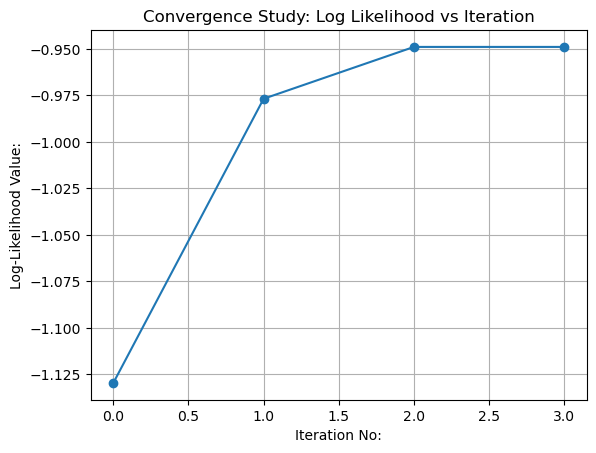

In [13]:
# Plot log_likelihood over iterations
plt.figure()
plt.plot(log_likelihoods, marker = 'o')
plt.xlabel('Iteration No:')
plt.ylabel('Log-Likelihood Value:')
plt.title("Convergence Study: Log Likelihood vs Iteration")
plt.grid(True)
plt.show()